# Central Limit Theorem

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/central_limit_theorem.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-21*

## Learning objectives

- Draw repeated samples from Gaussian, lognormal, and uniform distributions, take their means, and look at the distribution of those means.
- Verify empirically that the sample-mean distribution is approximately normal with mean $\mu$ and standard deviation $\sigma/\sqrt{N}$.
- See how the sample size $N$ required for the normal approximation depends on the shape of the underlying distribution.

The **Central Limit Theorem (CLT)** says that, no matter what distribution a random variable comes from, the distribution of *sample means* approaches a normal distribution as the sample size $N$ grows. Specifically, if the underlying random variable has mean $\mu$ and standard deviation $\sigma$, then sample means of size $N$ are approximately distributed as

$$\overline{x}_N \sim \mathcal{N}\!\left(\mathrm{mean}=\mu,\; \mathrm{std}=\sigma/\sqrt{N}\right).$$

Below we test this empirically: draw many samples, compute their means, and compare the resulting histograms to the theoretical normal curve.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

# Seeded random generator so the figures reproduce across runs.
rng = np.random.default_rng(seed=2026)

## Gaussian example

Start simple: draw samples from a *standard normal* distribution ($\mu=0$, $\sigma=1$) with three different sample sizes, $N=5$, $25$, and $100$. For each $N$, draw 10,000 samples, compute the mean of each one, and plot the histogram of those 10,000 means. The CLT predicts that these histograms should look like normal distributions centered on $0$ with standard deviation $1/\sqrt{N}$.

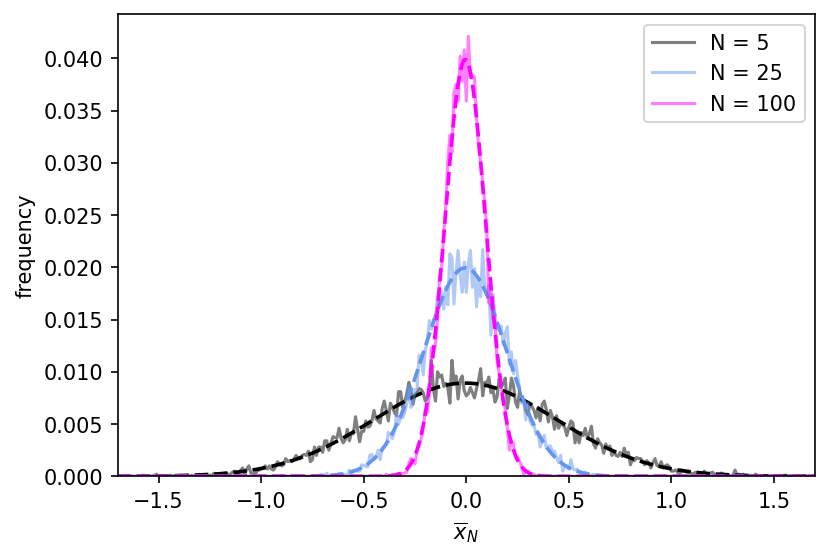

In [2]:
bin_width = 0.01
bins = np.arange(-8, 8, bin_width)
x = bins[:-1]
n_trials = 10_000

# Sample sizes to compare, each with its own plot color.
size_to_color = {5: "black", 25: "cornflowerblue", 100: "magenta"}

plt.figure()
for N, color in size_to_color.items():
    sample_means = []
    for _ in range(n_trials):
        sample = rng.normal(loc=0, scale=1.0, size=N)
        sample_means.append(np.mean(sample))

    hist, _ = np.histogram(sample_means, bins=bins)
    plt.plot(x, hist / n_trials, alpha=0.5, color=color, label=f"N = {N}")

    # Theoretical CLT prediction: normal with std = 1/sqrt(N).
    theory = bin_width * stats.norm.pdf(
        x + bin_width / 2, loc=0, scale=1.0 / np.sqrt(N)
    )
    plt.plot(x, theory, color=color, linestyle="--", linewidth=1.75)

plt.legend()
plt.xticks(np.arange(-2, 2, 0.5))
plt.xlim(-1.7, 1.7)
plt.ylim(bottom=0)
plt.xlabel(r"$\overline{x}_N$")
plt.ylabel("frequency")
plt.show()

Solid lines are the sample-mean histograms; dashed lines are the CLT prediction. The two agree closely even at $N=5$. (For very small $N$ the normal approximation is not exactly right — the $t$-distribution is the better fit. We will come back to that later.)

## Non-Gaussian examples

Starting from a Gaussian underplays how strong the CLT really is — of course Gaussian samples produce Gaussian means. The deeper claim is that *any* underlying distribution leads to normal sample means once $N$ is large enough. To test that, we'll use three quite different distributions:

- a **lognormal** (heavy right tail),
- a **uniform** on $[-5, 5]$ (flat, bounded),
- a **standard normal** (for reference).

First, let's look at the shapes of these three underlying distributions.

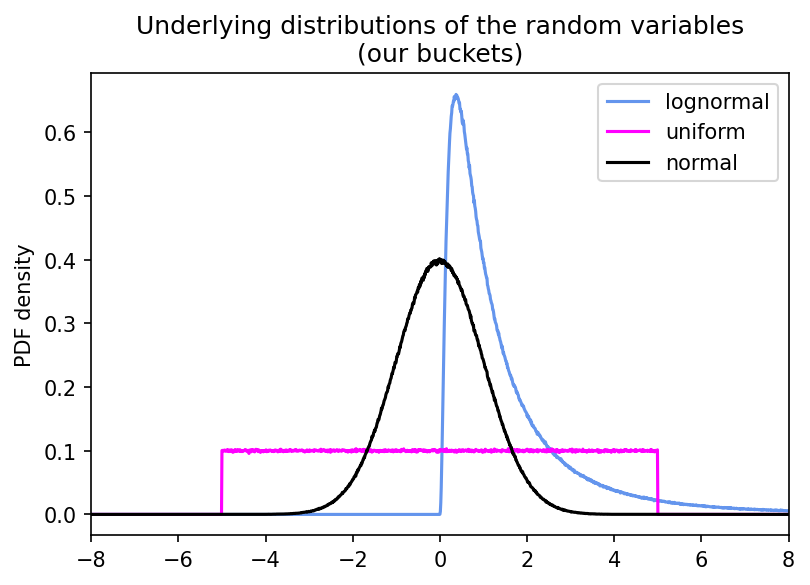

In [3]:
n_population = 10_000_000
xinc = 0.01
xbins = np.arange(-10, 10, xinc)

# Large draws used purely to visualize each underlying distribution.
r_log = rng.lognormal(0.0, 1.0, size=n_population)
r_uni = rng.uniform(-5.0, 5.0, size=n_population)
r_norm = rng.normal(0, 1, size=n_population)

plt.figure()
for samples, color, label in (
    (r_log, "cornflowerblue", "lognormal"),
    (r_uni, "magenta", "uniform"),
    (r_norm, "black", "normal"),
):
    counts, edges = np.histogram(samples, bins=xbins)
    plt.plot(edges[:-1], counts / (n_population * xinc), "-", color=color, label=label)

plt.legend()
plt.ylabel("PDF density")
plt.xlim(-8, 8)
plt.title("Underlying distributions of the random variables\n(our buckets)")
plt.show()

Now, for each sample size $N$, we will draw 10,000 samples of size $N$ from each of the three distributions, take the mean of every sample, and plot the histogram of those means. As $N$ grows, the CLT predicts that all three histograms — including the lognormal and uniform ones — should approach normal distributions, even though the underlying distributions themselves are nothing like a Gaussian.

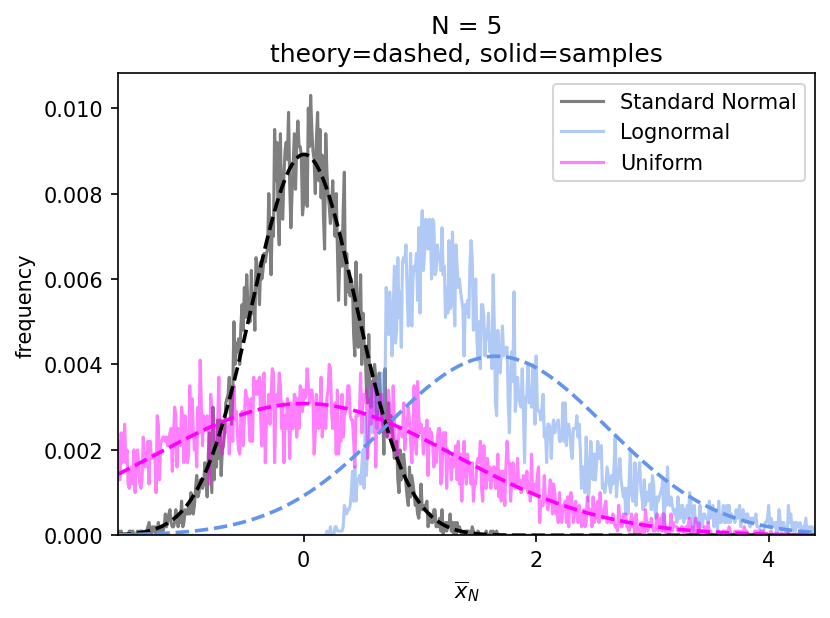

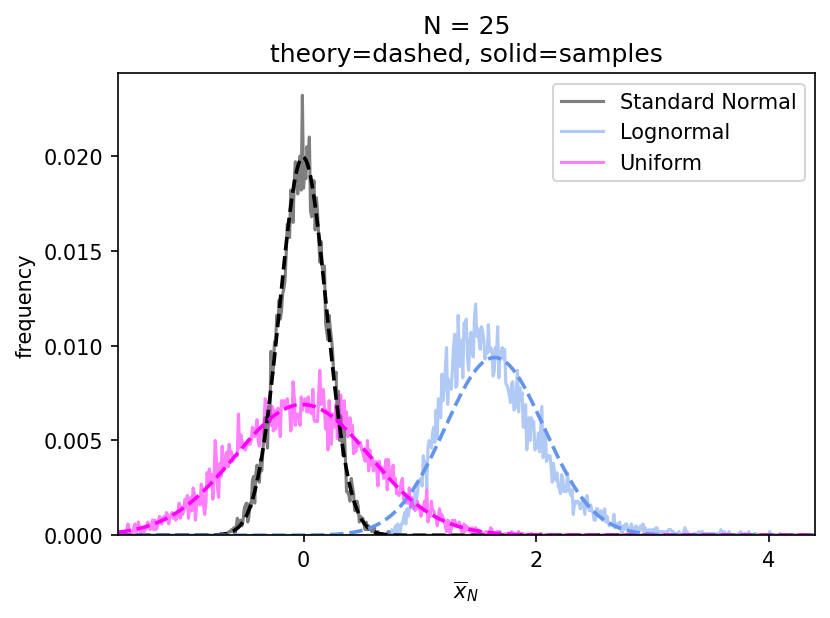

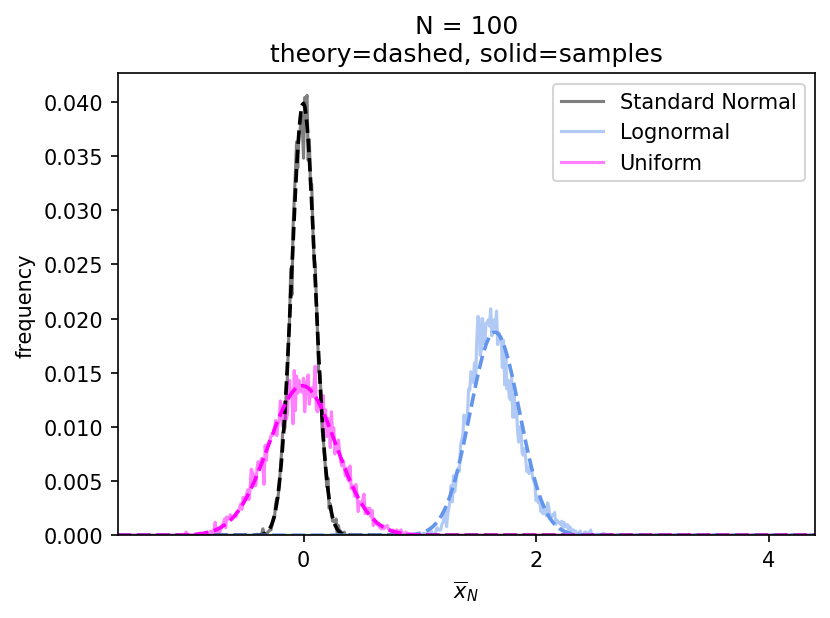

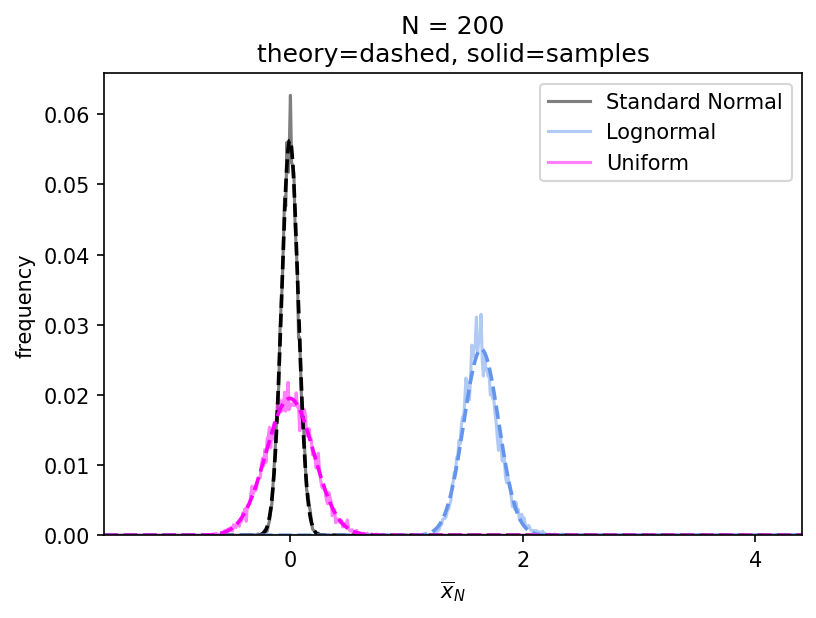

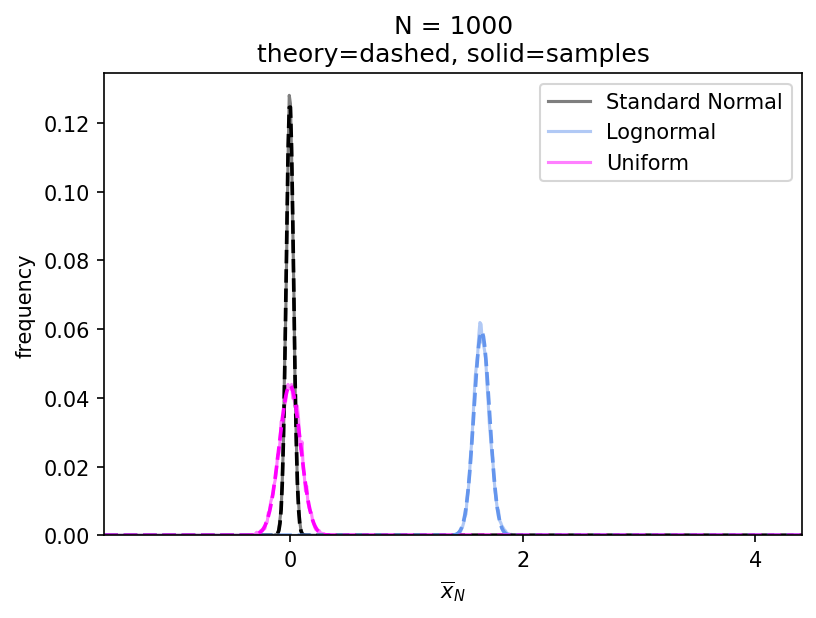

In [4]:
bin_width = 0.01
bins = np.arange(-8, 8, bin_width)
x = bins[:-1]
n_trials = 10_000
n_population = 100_000

# Population standard deviations (computed once, reused for every N).
sigma_norm = np.std(rng.normal(loc=0, scale=1, size=n_population))
sigma_log = np.std(rng.lognormal(mean=0, sigma=1, size=n_population))
sigma_uni = np.std(rng.uniform(low=-5, high=5, size=n_population))

for N in (5, 25, 100, 200, 1000):
    means_norm = []
    means_log = []
    means_uni = []

    for _ in range(n_trials):
        means_norm.append(np.mean(rng.normal(loc=0, scale=1.0, size=N)))
        means_log.append(np.mean(rng.lognormal(mean=0, sigma=1, size=N)))
        means_uni.append(np.mean(rng.uniform(low=-5, high=5, size=N)))

    hist_norm, _ = np.histogram(means_norm, bins=bins)
    hist_log, _ = np.histogram(means_log, bins=bins)
    hist_uni, _ = np.histogram(means_uni, bins=bins)

    plt.figure()
    plt.plot(x, hist_norm / n_trials, alpha=0.5, color="black", label="Standard Normal")
    plt.plot(
        x, hist_log / n_trials, alpha=0.5, color="cornflowerblue", label="Lognormal"
    )
    plt.plot(x, hist_uni / n_trials, alpha=0.5, color="magenta", label="Uniform")

    # CLT theory curves: normal(mean = sample mean, std = sigma_pop / sqrt(N)).
    plt.plot(
        x,
        bin_width
        * stats.norm.pdf(
            x + bin_width / 2, loc=np.mean(means_norm), scale=sigma_norm / np.sqrt(N)
        ),
        color="black",
        linestyle="--",
        linewidth=1.75,
    )
    plt.plot(
        x,
        bin_width
        * stats.norm.pdf(
            x + bin_width / 2, loc=np.mean(means_log), scale=sigma_log / np.sqrt(N)
        ),
        color="cornflowerblue",
        linestyle="--",
        linewidth=1.75,
    )
    plt.plot(
        x,
        bin_width
        * stats.norm.pdf(
            x + bin_width / 2, loc=np.mean(means_uni), scale=sigma_uni / np.sqrt(N)
        ),
        color="magenta",
        linestyle="--",
        linewidth=1.75,
    )

    plt.xticks(np.arange(-10, 10, 2))
    plt.xlim(-1.6, 4.4)
    plt.ylim(bottom=0)
    plt.xlabel(r"$\overline{x}_{N}$")
    plt.ylabel("frequency")
    plt.title(f"N = {N}\ntheory=dashed, solid=samples")
    plt.legend()
    plt.show()

For small $N$ — especially $N=5$ — the theoretical curve (dashed) doesn't fit the lognormal sample means well; the uniform is borderline, and the already-normal random variable lines up cleanly. As $N$ grows, all three sample-mean distributions converge to their CLT predictions. The lognormal is the slowest to converge because its heavy right tail puts extra weight in the mean for small samples. The CLT promises that convergence *will* happen — it just doesn't tell you how large $N$ has to be before it does. That depends on how non-Gaussian the underlying distribution is, and figuring that out for your own data is part of the job.

## Wrap-up

- Sample means concentrate: as $N$ grows the spread of $\overline{x}_N$ shrinks like $1/\sqrt{N}$.
- Sample means approach normality: even when the underlying distribution is skewed (lognormal) or flat (uniform), the histogram of sample means approaches a normal curve as $N$ grows.
- "Large enough $N$" is distribution-dependent. Heavier-tailed or more skewed underlying distributions require larger $N$ before the CLT looks like a good approximation.